In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [2]:
df=pd.read_csv("gender_classification_v7.csv")
print(f"veri boyutu:{df.shape}")
df.info()

veri boyutu:(5001, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [3]:
df.isnull().sum()

,0
long_hair,0
forehead_width_cm,0
forehead_height_cm,0
nose_wide,0
nose_long,0
lips_thin,0
distance_nose_to_lip_long,0
gender,0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
long_hair,5001.0,0.869626,0.336748,0.0,1.0,1.0,1.0,1.0
forehead_width_cm,5001.0,13.181484,1.107128,11.4,12.2,13.1,14.0,15.5
forehead_height_cm,5001.0,5.946311,0.541268,5.1,5.5,5.9,6.4,7.1
nose_wide,5001.0,0.493901,0.500013,0.0,0.0,0.0,1.0,1.0
nose_long,5001.0,0.507898,0.499988,0.0,0.0,1.0,1.0,1.0
lips_thin,5001.0,0.493101,0.500002,0.0,0.0,0.0,1.0,1.0
distance_nose_to_lip_long,5001.0,0.498900,0.500049,0.0,0.0,0.0,1.0,1.0


In [5]:
df.head(2)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female


In [6]:
X_features = df.drop(columns="gender")

imputer =SimpleImputer(strategy="mean")
df_imputed =pd.DataFrame(imputer.fit_transform(X_features),columns=X_features.columns,index=X_features.index)
print(f"Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}")

Eksik deger kaldi mi: 0


In [7]:
scaler =StandardScaler()
X_scaled =scaler.fit_transform(df_imputed)
df_scaled =pd.DataFrame(X_scaled,columns=df_imputed.columns,index=df_imputed.index)
df_scaled.head(2)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
0,0.387194,-1.247933,0.283971,1.012273,-1.015924,1.013894,1.002202
1,-2.582682,0.739389,-1.009418,-0.987876,-1.015924,1.013894,-0.997803


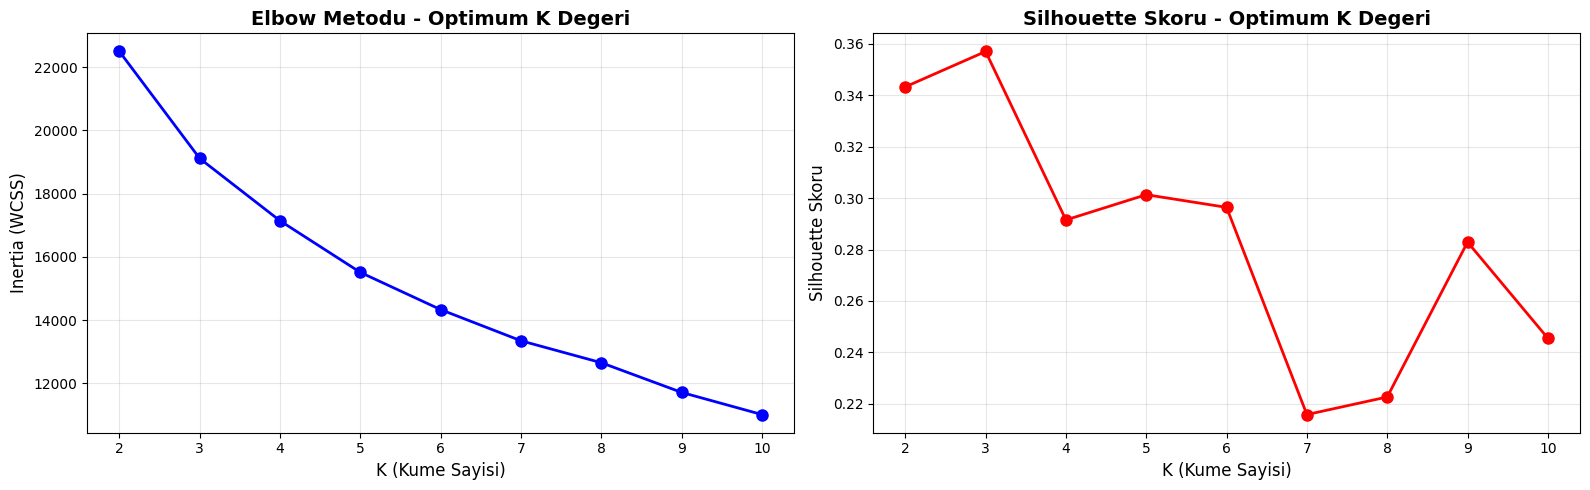

En iyi silhoutte skoru: 0.3571
Optimum K degeri: 3


In [8]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Gorsellestirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhoutte skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

In [9]:
optimal_k = 3  # Elbow ve silhouette analizine gore
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 3
Silhouette Skoru: 0.3571
Davies-Bouldin Indeksi: 1.2580
Calinski-Harabasz Skoru: 2078.2383

Kume dagilimi:
0    2190
1    2159
2     652
Name: count, dtype: int64


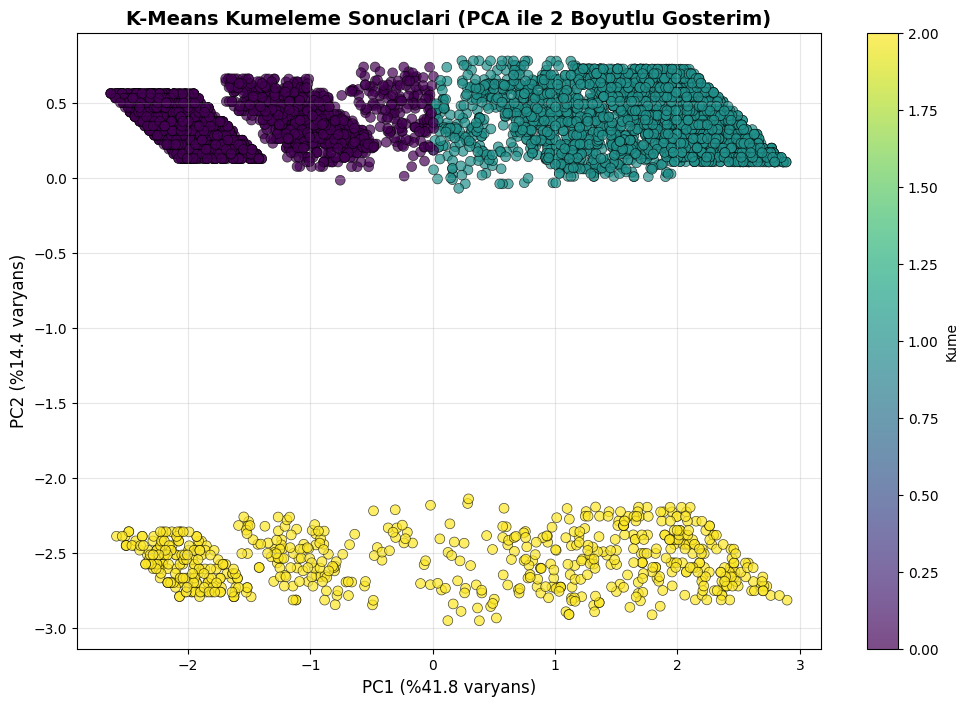

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

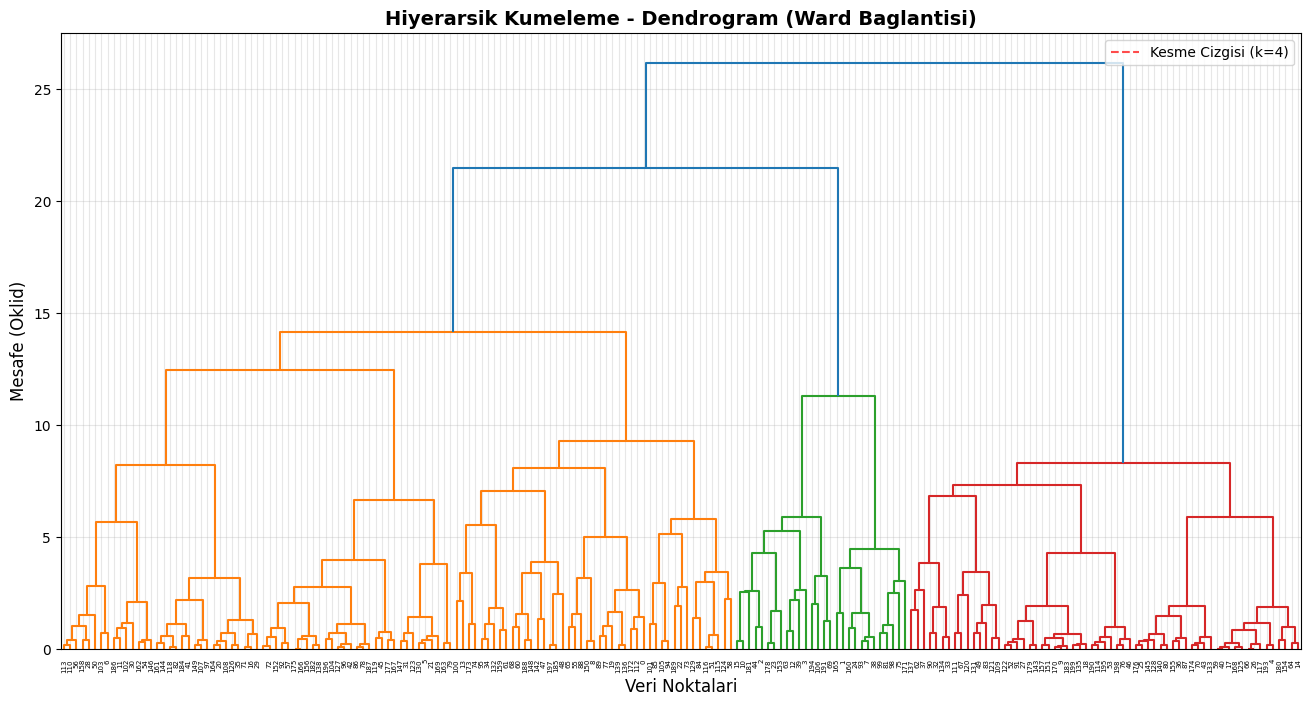

In [11]:
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled[:200], method='ward')  # Gorsellestirme icin 200 ornek
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Kesme Cizgisi (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 3
Baglanti yontemi: ward
Silhouette Skoru: 0.3078
Davies-Bouldin Indeksi: 1.3558
Calinski-Harabasz Skoru: 1694.3557

Kume dagilimi:
0    2664
1    1685
2     652
Name: count, dtype: int64


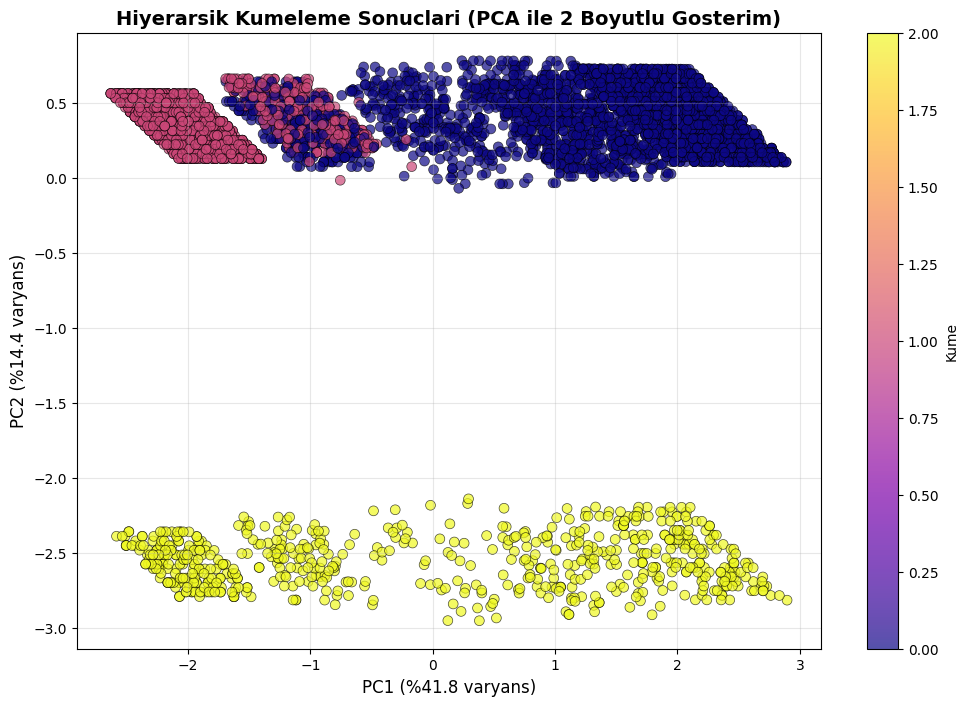

In [13]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

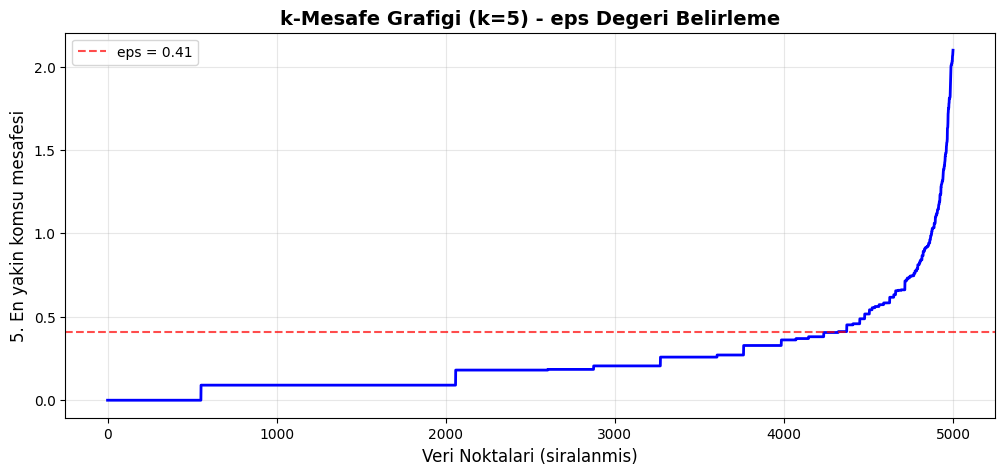

In [14]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=0.41, color='r', linestyle='--', alpha=0.7, label='eps = 0.41')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
dbscan = DBSCAN(eps=0.41, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 0.41, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kumeleme Sonuclari:
eps: 0.41, min_samples: 5
Olusan kume sayisi: 32
Gurultu (aykiri deger) sayisi: 504
Gurultu orani: 10.08%
Silhouette Skoru: 0.2127
Davies-Bouldin Indeksi: 1.3341
Calinski-Harabasz Skoru: 304.8774

Kume dagilimi:
-1      504
 0      147
 1       12
 2     1285
 3     1281
 4      144
 5      190
 6       30
 7      131
 8      175
 9      190
 10      27
 11     205
 12     167
 13     172
 14     189
 15       7
 16      26
 17      10
 18      11
 19       7
 20       5
 21       9
 22       6
 23       7
 24      15
 25       6
 26      11
 27       7
 28       5
 29       5
 30      10
 31       5
Name: count, dtype: int64


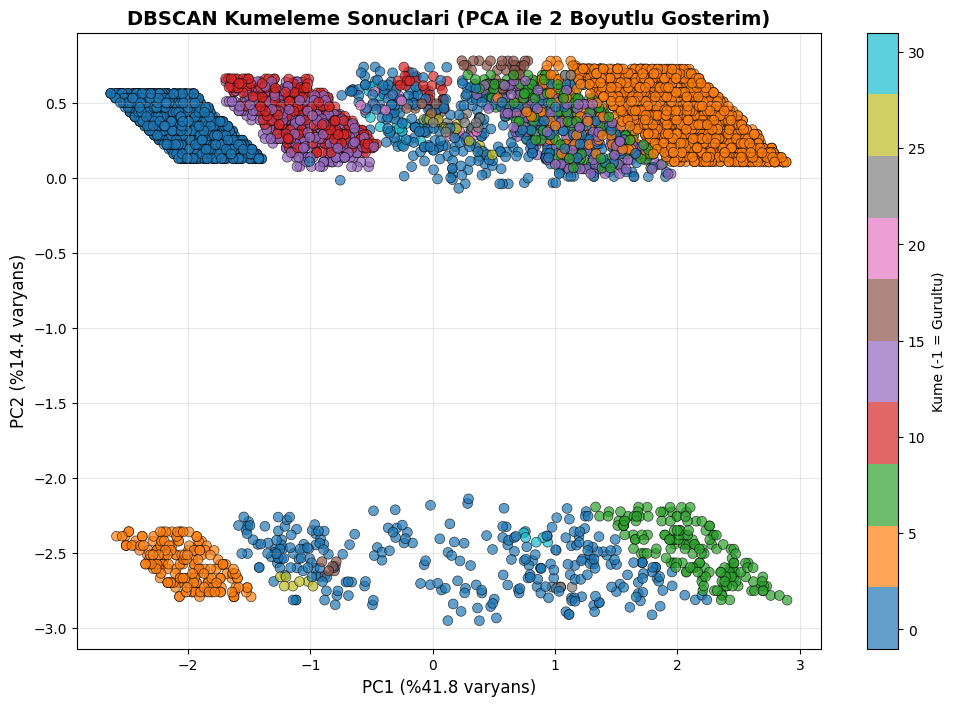

In [16]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
## **Decision Tree****

In [18]:
import random
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,classification_report,ConfusionMatrixDisplay,RocCurveDisplay)

In [19]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)

X = df.drop(columns="gender").values
y = df["gender"].values
feature_names = df.drop(columns="gender").columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
dt_grid= GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      param_grid={
                          "criterion":["gini","entropy"],
                          "splitter":["best","random"],
                          "max_depth":[3,4,5,6,8,None],
                          "min_samples_leaf" :[1,2,5,10]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1)
dt_grid.fit(X_train,y_train)
dt=dt_grid.best_estimator_
print("En iyi parametre:", dt_grid.best_params_)

En iyi parametre: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5, 'splitter': 'best'}


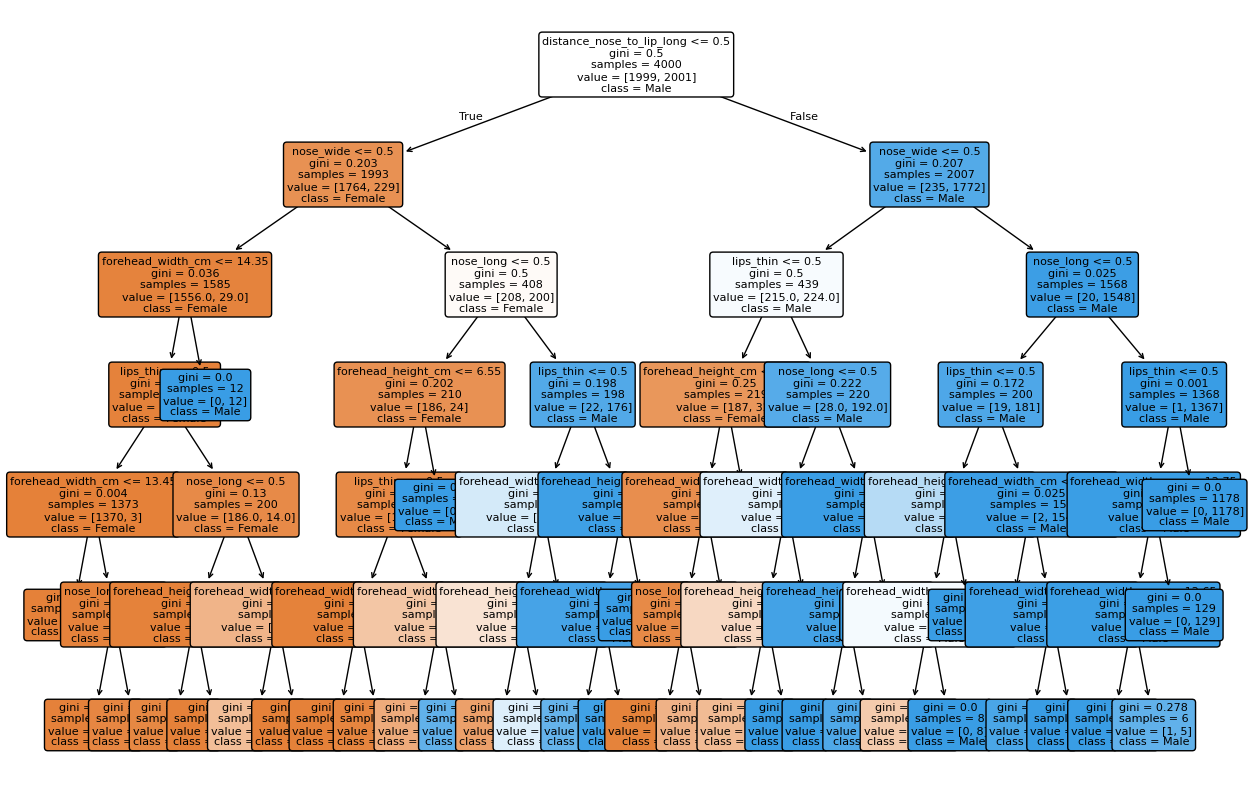

In [21]:
plt.figure(figsize=(15,10))
plot_tree(dt,feature_names=feature_names,class_names=dt.classes_,
          filled=True,rounded= True, max_depth= 8, fontsize =8)
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_grid= GridSearchCV(RandomForestClassifier(random_state=SEED),
                      param_grid={
                          "n_estimators":[100,200],
                          "max_depth":[5,7],
                          "min_samples_leaf" :[1,2],
                          "min_samples_split":[2,5],
                          "max_features":["sqrt","log2"],
                          "criterion":["gini","entropy"],
                          "bootstrap":[True,False]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1,verbose =1)
rf_grid.fit(X_train,y_train)
rf=rf_grid.best_estimator_
print("En iyi parametre:", rf_grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
En iyi parametre: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


======== Decision Tree ========
Test dogrulugu: 0.9660
Ortalama 5 katli CV dogrulugu: 0.9730
              precision    recall  f1-score   support

      Female       0.95      0.98      0.97       502
        Male       0.98      0.95      0.97       499

    accuracy                           0.97      1001
   macro avg       0.97      0.97      0.97      1001
weighted avg       0.97      0.97      0.97      1001

======== Random Forest ========
Test dogrulugu: 0.9670
Ortalama 5 katli CV dogrulugu: 0.9783
              precision    recall  f1-score   support

      Female       0.96      0.98      0.97       502
        Male       0.98      0.95      0.97       499

    accuracy                           0.97      1001
   macro avg       0.97      0.97      0.97      1001
weighted avg       0.97      0.97      0.97      1001



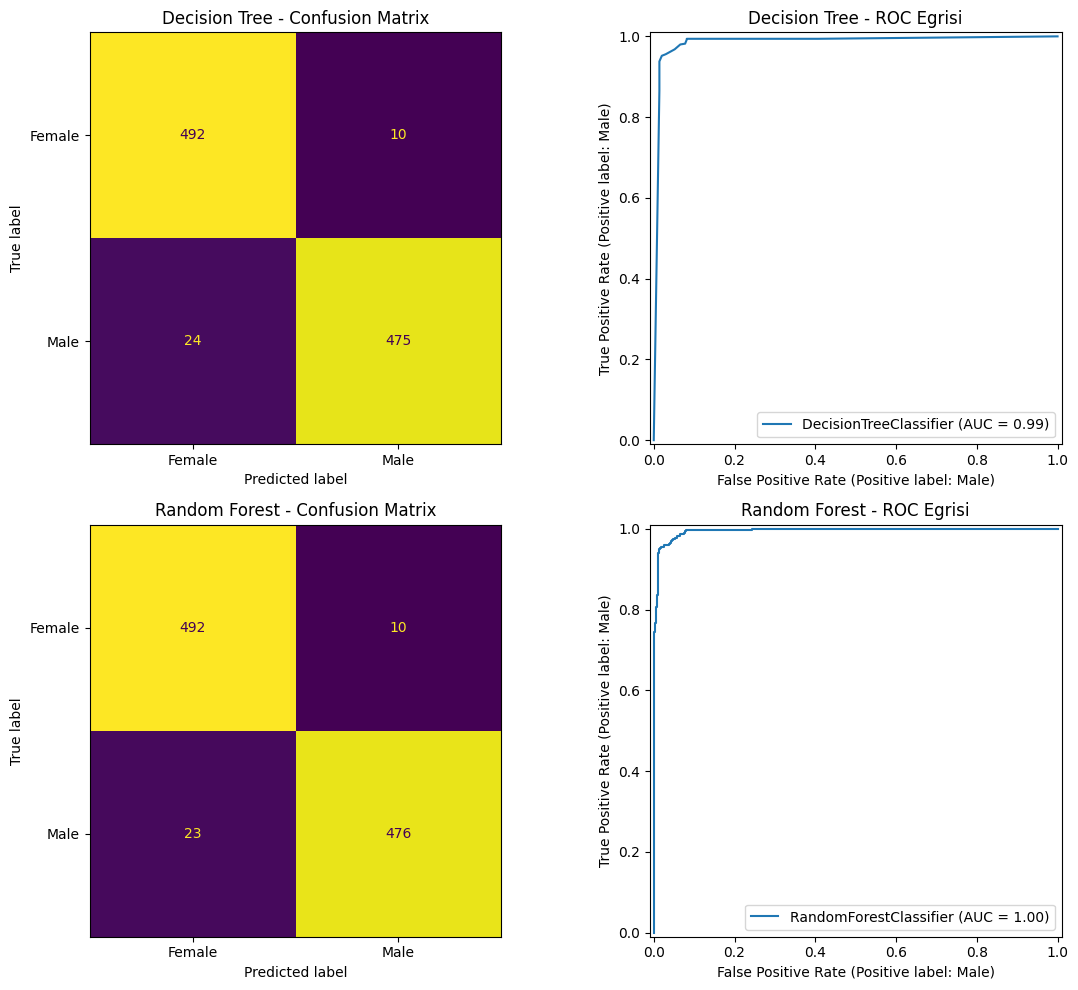

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (name, model) in enumerate([("Decision Tree", dt), ("Random Forest", rf)]):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"======== {name} ========")
    print(f"Test dogrulugu: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Ortalama 5 katli CV dogrulugu: {np.mean(cv_scores):.4f}")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=axes[i, 0], colorbar=False)
    axes[i, 0].set_title(f"{name} - Confusion Matrix")

    RocCurveDisplay.from_estimator(model, X_test, y_test, pos_label="Male", ax=axes[i, 1])
    axes[i, 1].set_title(f"{name} - ROC Egrisi")

plt.tight_layout()
plt.savefig("confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

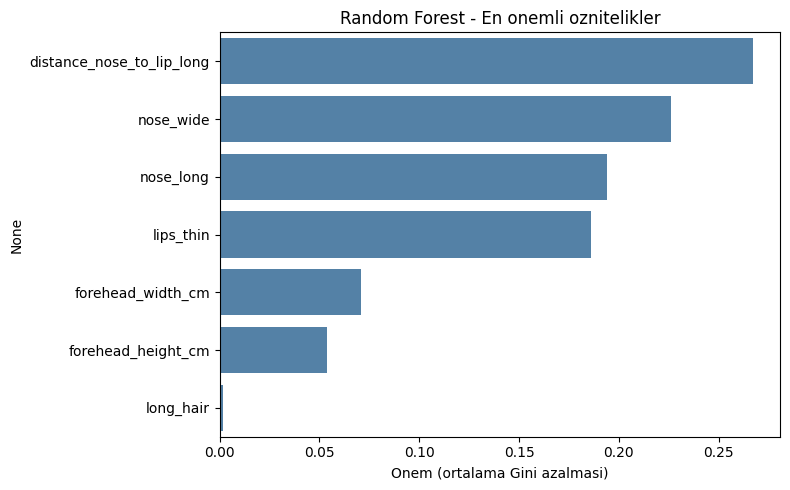

Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png


In [26]:
imp = pd.Series(rf.feature_importances_, index=feature_names).nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.xlabel("Onem (ortalama Gini azalmasi)")
plt.title("Random Forest - En onemli oznitelikler")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png")